<a href="https://colab.research.google.com/github/KHUSHINATARAJ/ML_LAB_6TH_SEM/blob/main/Binary_Logistic__Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from matplotlib import pyplot as plt

In [5]:
import pandas as pd
from google.colab import files
import io

file_name = "insurance_data.csv"

try:
    df = pd.read_csv(file_name)
    print(f"Successfully loaded '{file_name}'.")
    print(df.head())
except FileNotFoundError:
    print(f"Error: The file '{file_name}' was not found in the current environment.")
    print("Please ensure the file is uploaded. You can upload it now:")
    uploaded = files.upload()
    if file_name in uploaded:
        # Assuming the file is now in the current directory after upload
        try:
            df = pd.read_csv(file_name)
            print(f"'{file_name}' uploaded and loaded successfully.")
            print(df.head())
        except Exception as e:
            print(f"Error reading '{file_name}' after upload: {e}")
            df = None
    else:
        print(f"'{file_name}' was not among the uploaded files or the upload was cancelled.")
        df = None
except Exception as e:
    print(f"An unexpected error occurred while trying to read '{file_name}': {e}")
    df = None

Error: The file 'insurance_data.csv' was not found in the current environment.
Please ensure the file is uploaded. You can upload it now:


Saving insurance_data.csv to insurance_data.csv
'insurance_data.csv' uploaded and loaded successfully.
   age  bought_insurance
0   22                 0
1   25                 0
2   47                 1
3   52                 0
4   46                 1


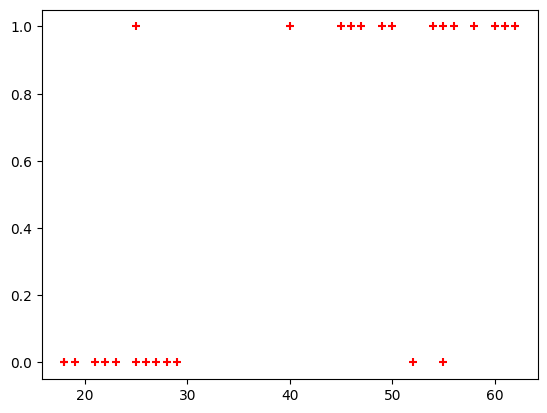

In [6]:
plt.scatter(df.age, df.bought_insurance, marker='+', color='red')

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    df[['age']],
    df.bought_insurance,
    train_size=0.9,
    random_state=10
)

In [10]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [11]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [12]:
y_predicted = model.predict(X_test)

In [13]:
model.score(X_test, y_test)

1.0

In [14]:
model.predict_proba(X_test)

array([[0.06470655, 0.93529345],
       [0.10327333, 0.89672667],
       [0.92775258, 0.07224742]])

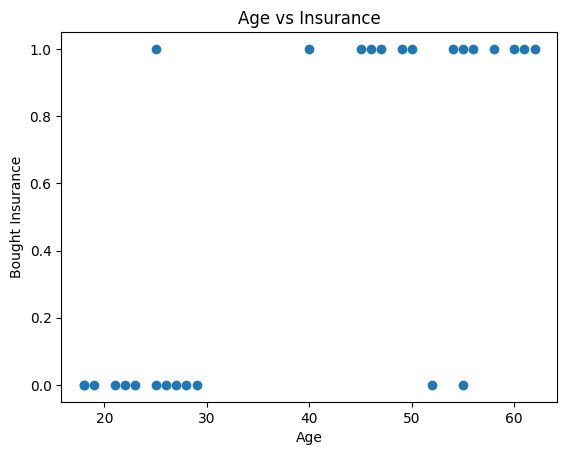

In [15]:
plt.scatter(df.age, df.bought_insurance)
plt.xlabel("Age")
plt.ylabel("Bought Insurance")
plt.title("Age vs Insurance")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


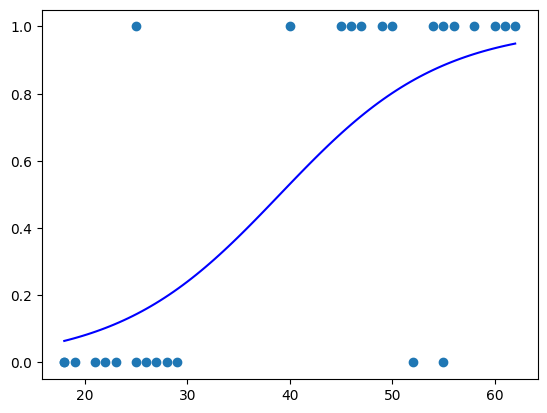

In [16]:
import numpy as np

ages = np.linspace(df.age.min(), df.age.max(), 100)
prob = model.predict_proba(ages.reshape(-1,1))[:,1]

plt.scatter(df.age, df.bought_insurance)
plt.plot(ages, prob, color='blue')
plt.show()